# **Generative AI for Computer Vision**: HW1 - Image Classification using CNNs

**CSCE 689 — Fall 2026 (AI4CV)**

In this assignment, you will practice training a CNN from scratch on Tiny-ImageNet, which is a smaller version of ImageNet with 200 classes. Each class contains 500 images in the training set and 50 images in the testing set. The goals of this assignment are as follows:

- Understand the data-driven Image Classification pipeline (train/predict stages).
- Understand the train/val/test splits and the use of validation data for hyperparameter tuning.
- Learn how to finetune the pretrained model on the downstream task.

## Part 1: Training a CNN from scratch on Tiny ImageNet
In this part, you will train a CNN model from scratch, and evaluate your model on the given test set.
To finish this part, you will have to:
1. The data is split into train/val/test, the validation data is randomly selected from the training set, and the testing set is fixed. It is recommeded to do data augmentations, such as slight rotation. Please visit this website for more details: https://pytorch.org/vision/main/transforms.html
2. Create a customized CNN model at your own, any techniques, such as dropout, normalizations, are all welcomed!
3. Plot the training accuracy curve, report the testing accuracy and plot the confusion matrix.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch import Tensor
from typing import Type

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import pdb

import kagglehub

### Step 1: Download the Tiny ImageNet dataset from Kaggle
Please DO NOT modify this cell.

In [3]:
# Download tiny imagenet
base_dir = kagglehub.dataset_download("huchanwei123/cvrp-tinyimagenet")
print("Path to dataset files:", base_dir)
train_dir = os.path.join(base_dir, 'tiny-imagenet/train')
test_dir = os.path.join(base_dir, 'tiny-imagenet/test')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Using Colab cache for faster access to the 'cvrp-tinyimagenet' dataset.
Path to dataset files: /kaggle/input/cvrp-tinyimagenet


### Step 2: Create the data loader, and split it to train/val
1. The original folder structure is: \
   ├── train \
│   ├── labels (such as n01443537) \
│   │   ├── images \
│   │   │   ├── n01443537_0.JPEG \
│   │   │   ├── n01443537_1.JPEG \
│   │   │   ├── ... \
   It is highly recommended to use ```dataset.ImageFolder``` to load the data!
2. To check how to transform your data, check here: https://pytorch.org/vision/main/transforms.html
3. Later when you train the model, you might need to tune hyperparameters. For example, you may not want the fixed learning rate.


In [4]:
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder

# Parameters
img_size = 64

# Hyper-parameters for the training (NOTE: you can tune it!)
learning_rate = 3e-4
batch_size = 32
num_epochs = 50
num_classes = 200

######################################### Data Loaders ##########################################
# For example, you might want to resize the image first so your model can take any input size.
# >   train_transforms = transforms.Compose([
#          transforms.Resize((img_size, img_size)),
#          transforms.ToTensor(),
#     ])
#################################################################################################
#                                         Your code here                                        #
#################################################################################################

normalize = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomCrop(img_size, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    normalize,
])

val_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    normalize,
])

train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(train_dir, transform=val_transforms)

### Define the split ratio (e.g., 80% train, 20% validation)
# Your code
train_ratio = 0.8
val_ratio = 0.2


### Split the dataset, ex: using random_split 
# Your code
train_size = int(train_ratio * len(train_dataset))
val_size = len(train_dataset) - train_size
train_split, val_split = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_set = train_split
val_set = Subset(val_dataset, val_split.indices)

### Create data loaders with Pytorch DataLoader
# Your code
train_loader = DataLoader(train_set, batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size, shuffle=False)

### Step 3: Create your own CNN!
More details can be found here: https://www.digitalocean.com/community/tutorials/writing-cnns-from-scratch-in-pytorch

In [5]:
### Define the custom CNN model
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)


class yourCNN(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(32, 32, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(32, 64, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    @staticmethod
    def _make_layer(in_channels, out_channels, num_blocks, stride):
        blocks = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            blocks.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.classifier(x)

### Step 4: We are now ready to train the CNN model!
1. Define your model with your CNN class!
2. Define the loss function (```CrossEntropyLoss()```?) and the optimizer. More details can be found here: https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

In [6]:
### Define the model
model = yourCNN(num_classes=num_classes).to(device)

### Define the Loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4,
)

### Step 5: Implement your training procedure!
#### For training:
1. Iterate through each batch in the train dataloader
2. Reset the optimizer
3. Calculate the loss
4. Do backpropagation!
5. Keep track of the loss and accuracy when finishing this epoch

#### For evaluating:
Similar to the training process, but DON'T train the model! Only prediction!

**NOTE**: It is to modify the in/out arguments of ```train_model``` function

In [7]:
### Training function
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs,
    checkpoint_path=None,
    resume=False,
    scheduler=None,
    best_model_path=None,
):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    start_epoch = 0
    best_val_accuracy = float("-inf")

    if resume:
        if not checkpoint_path:
            raise ValueError("checkpoint_path is required when resume=True")
        if os.path.isfile(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
                scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            start_epoch = checkpoint["epoch"]
            train_losses = checkpoint["train_losses"]
            val_losses = checkpoint["val_losses"]
            train_accuracies = checkpoint["train_accuracies"]
            val_accuracies = checkpoint["val_accuracies"]
            print(f"Resuming from epoch {start_epoch}")

            if best_model_path and os.path.isfile(best_model_path):
                best_checkpoint = torch.load(best_model_path, map_location=device)
                best_val_accuracy = best_checkpoint["val_accuracy"]
            elif best_model_path and val_accuracies:
                best_val_accuracy = val_accuracies[-1]
                best_model_dir = os.path.dirname(best_model_path)
                if best_model_dir:
                    os.makedirs(best_model_dir, exist_ok=True)
                torch.save(
                    {
                        "epoch": start_epoch,
                        "model_state_dict": model.state_dict(),
                        "val_accuracy": best_val_accuracy,
                    },
                    best_model_path,
                )
        else:
            print("No checkpoint found; starting from scratch")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        train_loss_total = 0.0
        train_correct = 0
        train_total = 0

        for batch_index, (inputs, labels) in enumerate(train_loader, start=1):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_count = labels.size(0)
            train_loss_total += loss.item() * batch_count
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_total += batch_count

            if batch_index % 500 == 0 or batch_index == len(train_loader):
                print(
                    f"Epoch [{epoch + 1}/{num_epochs}] "
                    f"Batch [{batch_index}/{len(train_loader)}] "
                    f"Train Loss: {train_loss_total / train_total:.4f}, "
                    f"Train Accuracy: {train_correct / train_total:.4f}",
                    flush=True,
                )

        train_losses.append(train_loss_total / train_total)
        train_accuracies.append(train_correct / train_total)

        model.eval()
        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                batch_count = labels.size(0)
                val_loss_total += loss.item() * batch_count
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += batch_count

        val_losses.append(val_loss_total / val_total)
        val_accuracies.append(val_correct / val_total)

        if scheduler is not None:
            scheduler.step(val_losses[-1])

        if best_model_path and val_accuracies[-1] > best_val_accuracy:
            best_val_accuracy = val_accuracies[-1]
            best_model_dir = os.path.dirname(best_model_path)
            if best_model_dir:
                os.makedirs(best_model_dir, exist_ok=True)
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "val_accuracy": best_val_accuracy,
                },
                best_model_path,
            )

        if checkpoint_path and ((epoch + 1) % 5 == 0 or epoch + 1 == num_epochs):
            checkpoint_dir = os.path.dirname(checkpoint_path)
            if checkpoint_dir:
                os.makedirs(checkpoint_dir, exist_ok=True)
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "train_accuracies": train_accuracies,
                    "val_accuracies": val_accuracies,
                },
                checkpoint_path,
            )

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_losses[-1]:.4f}, "
            f"Train Accuracy: {train_accuracies[-1]:.4f}, "
            f"Val Loss: {val_losses[-1]:.4f}, "
            f"Val Accuracy: {val_accuracies[-1]:.4f}, "
            f"LR: {optimizer.param_groups[0]['lr']:.6g}"
        )

    return train_losses, val_losses, train_accuracies, val_accuracies, model

### Step 6: Start training the model!
Actually nothing to do in this cell...

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import platform
print(platform.system())

Linux


In [10]:
print(device)
print(torch.cuda.is_available())

cuda
True


Resuming from epoch 30
Epoch [31/50] Batch [500/2500] Train Loss: 2.0278, Train Accuracy: 0.6899
Epoch [31/50] Batch [1000/2500] Train Loss: 2.0222, Train Accuracy: 0.6923
Epoch [31/50] Batch [1500/2500] Train Loss: 2.0219, Train Accuracy: 0.6921
Epoch [31/50] Batch [2000/2500] Train Loss: 2.0275, Train Accuracy: 0.6905
Epoch [31/50] Batch [2500/2500] Train Loss: 2.0329, Train Accuracy: 0.6895
Epoch [31/50] Train Loss: 2.0329, Train Accuracy: 0.6895, Val Loss: 2.6036, Val Accuracy: 0.5524, LR: 0.00015
Epoch [32/50] Batch [500/2500] Train Loss: 2.0034, Train Accuracy: 0.7043
Epoch [32/50] Batch [1000/2500] Train Loss: 2.0072, Train Accuracy: 0.6997
Epoch [32/50] Batch [1500/2500] Train Loss: 2.0103, Train Accuracy: 0.6965
Epoch [32/50] Batch [2000/2500] Train Loss: 2.0164, Train Accuracy: 0.6938
Epoch [32/50] Batch [2500/2500] Train Loss: 2.0174, Train Accuracy: 0.6932
Epoch [32/50] Train Loss: 2.0174, Train Accuracy: 0.6932, Val Loss: 2.6177, Val Accuracy: 0.5486, LR: 0.00015
Epoch [33

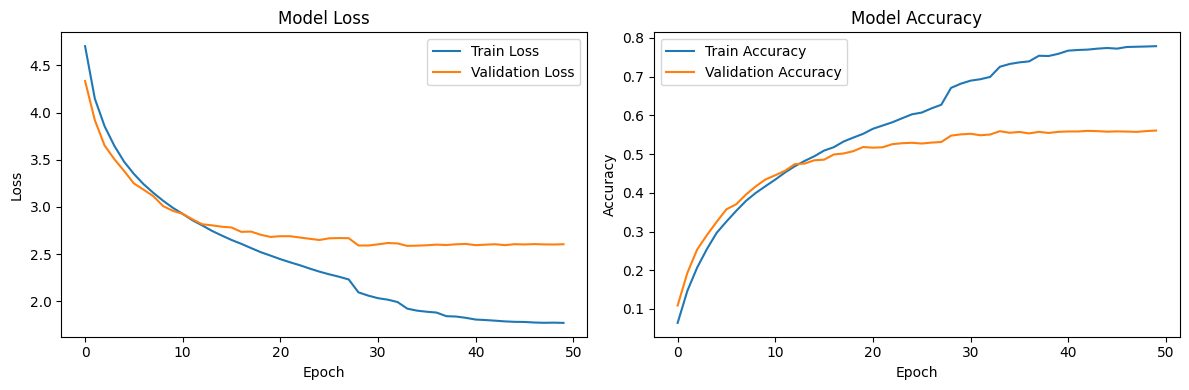

In [11]:
### Train the residual CNN with label smoothing and keep the best validation model
checkpoint_path = '/content/drive/MyDrive/Assignment1/cnn_resnet_ls_checkpoint.pth'
best_model_path = '/content/drive/MyDrive/Assignment1/cnn_resnet_ls_best_weights.pth'
resume_checkpoint = True

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

train_losses, val_losses, train_accuracies, val_accuracies, model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=50,
    checkpoint_path=checkpoint_path,
    resume=resume_checkpoint,
    scheduler=scheduler,
    best_model_path=best_model_path,
)

best_checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
print(f"Using best validation checkpoint from epoch {best_checkpoint['epoch']}")
torch.save(
    model.state_dict(),
    '/content/drive/MyDrive/Assignment1/CNN_resnet_ls_weights.pth',
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Step 7: Evaluate your model on testing set and plot the confusion matrix
In this part, you will learn to evaluate a trained model on testing set, and plot the confusion matrix.
Ideally, a great classification model would have non-zero values only along the diagonal, with zeros in all off-diagonal elements.

**HINTS**
1. Remember to perform the same transforms to your testing set as the validation set.
2. In ```get_predictions```, it is basically the same as you do evaluation.

Test Accuracy: 0.5543


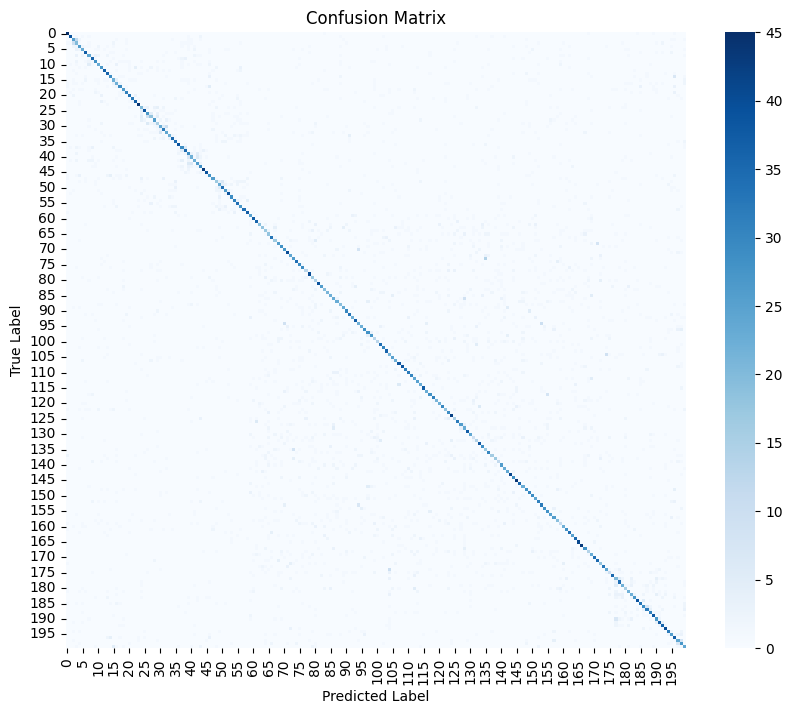

In [12]:
############################### Test Data Loader ##############################
###############################################################################
#                                 Your code here                              #
###############################################################################

test_dataset = ImageFolder(test_dir, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

### If you don't want to train the model again, you can restore it!
# ==> model.load_state_dict(torch.load('/path/to/your/saved/model.pth'))

# Change model to evaluation phase
model.eval()

# Function to get predictions and true labels
def get_predictions(model, dataloader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    #############################################################
    #                      Your code here                       #
    #############################################################
    return np.array(all_predictions), np.array(all_labels)


### Get predictions and true labels
predictions, true_labels = get_predictions(model, test_loader)

################# Compute confusion matrix ##################
#############################################################
# cm = ?                                                    #
#############################################################
cm = confusion_matrix(true_labels, predictions, labels=np.arange(num_classes))

### Calculate accuracy
accuracy = (predictions == true_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


### Questions
1. Did you observe overfitting? If yes, how did you address it?
2. The original dataset is well-balanced, that is, each class has the same number of training examples. However, this rarely happens in the real situation because some classes may dominate the training set. For example, in autonomous driving application, most training data are vehicles moving forward, while moving backwards take a small amount. This is called longtailed dataset. You will have to train the same CNN model on tiny-imagenet dataset with longtailed distribution.
   
   ```base_dir = kagglehub.dataset_download("huchanwei123/cvrp-tinyimagenet-lt")``` \
   ```train_dir = os.path.join(base_dir, 'tiny-imagenet-lt/train')``` \
   ```test_dir = os.path.join(base_dir, 'tiny-imagenet-lt/test')```

   Please plot out the trainig data distribuion (x-axis: class ID, y-axis: number of images), and analyze the performance compared to original dataset.
3. With your results trained on longtailed tiny-imagenet, you might observe the lower testing accuracy. Please try to improve the algorithm by performing a more **aggresive data augmentation** or **frequent re-sampling on tail classes**. (Note: Just try your best!)